In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
)

In [2]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [3]:
# --------------------------------------------------
# Amazon Product Reviews Dataset
# Source: UCI "Sentiment Labelled Sentences" (amazon_cells_labelled)
# 1000 real reviews, balanced. label: 1 = Positive, 0 = Negative
# --------------------------------------------------
CSV_PATH = "../../datasets/amazon_reviews_labelled.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Class balance:", df["label"].value_counts().to_dict())
df.head()

Shape: (1000, 2)
Class balance: {0: 500, 1: 500}


,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [4]:
# --------------------------------------------------
# NLP Preprocessing Function
# --------------------------------------------------
def preprocess_text(text):

    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Normalization
    tokens = [word.lower() for word in tokens]

    # 4. Stopword Removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # 5. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [5]:
# --------------------------------------------------
# Apply NLP Pipeline
# --------------------------------------------------
df["processed_review"] = df["review"].apply(preprocess_text)



In [6]:

# --------------------------------------------------
# TF-IDF Vectorization
# --------------------------------------------------
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df["processed_review"]
)

y = df["label"]

In [7]:
# --------------------------------------------------
# Train/Test Split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## Model Comparison

Train two classifiers on the **same** TF-IDF features and train/test split,
then compare them on accuracy, precision, recall, and F1:

- **Logistic Regression** — linear model, well-calibrated probabilities.
- **Linear SVM** (`LinearSVC`) — maximum-margin linear classifier, often the
  strongest of the two on sparse TF-IDF text features.

In [8]:
# --------------------------------------------------
# Train & score all models on the same split
# --------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM":          LinearSVC(),
}

results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    acc = accuracy_score(y_test, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, preds, average="binary", zero_division=0
    )
    results.append(
        {"Model": name, "Accuracy": acc,
         "Precision": precision, "Recall": recall, "F1": f1}
    )

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("F1", ascending=False)
)

print("Model comparison (sorted by F1):")
results_df.round(3)

Model comparison (sorted by F1):


,Accuracy,Precision,Recall,F1
Model,,,,
Linear SVM,0.813,0.840,0.786,0.812
Logistic Regression,0.787,0.841,0.721,0.776


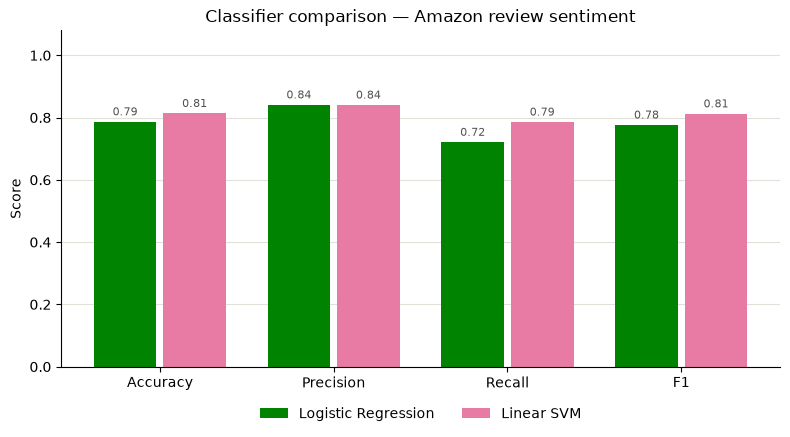

In [9]:
# --------------------------------------------------
# Visual comparison — grouped bars (metric on x, model = colored series)
# --------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1"]

# Fixed color per model (categorical slots), keyed by name so the color
# follows the model regardless of how the table is sorted.
model_colors = {
    "Logistic Regression": "#008300",  # green
    "Linear SVM":          "#e87ba4",  # magenta
}
model_order = list(model_colors)                       # stable legend order
x = np.arange(len(metrics))
width = 0.8 / len(model_order)

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, name in enumerate(model_order):
    vals = results_df.loc[name, metrics].to_numpy(dtype=float)
    offset = (i - (len(model_order) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width * 0.9,
                  label=name, color=model_colors[name])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8, color="#52514e")

ax.set_xticks(x, metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Classifier comparison — Amazon review sentiment")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.2))
plt.tight_layout()
plt.show()

## Stress-testing both models on confusing reviews

Both classifiers are **bag-of-words + TF-IDF linear models** — they score reviews on
which words appear, with no understanding of word *order*, negation, or sarcasm.
Below we hand **both** the Logistic Regression and the Linear SVM 10 deliberately
tricky reviews (negation, double negation, mixed sentiment, sarcasm, subtle tone)
and compare where each one breaks down.

In [11]:
# --------------------------------------------------
# Predict on deliberately confusing reviews — both models side by side
# --------------------------------------------------
confusing_reviews = [
    "The product is not good",                              # 1. Negation
    "I cannot say this product is not useful",              # 2. Double negation
    "The phone looks amazing but the battery is terrible",  # 3. Mixed sentiment
    "Great job, the product stopped working on the first day",  # 4. Sarcasm
    "Excellent design but horrible performance",            # 5. Pos + neg words
    "The camera is bad but everything else is perfect",     # 6. Context dependency
    "I expected much more from this product",               # 7. Subtle negative
    "It is not the worst product I have used",              # 8. Subtle positive
    "The device is absolutely phenomenal",                 # 9. Unseen vocabulary
    "It is okay, nothing special",                          # 10. Ambiguous
]

# What a human would label each (ground truth) for scoring the models.
expected = np.array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0])

# Reuse the SAME vectorizer fitted on the training corpus.
X_conf = vectorizer.transform([preprocess_text(r) for r in confusing_reviews])

label = {0: "Negative", 1: "Positive"}
conf_df = pd.DataFrame({
    "review": confusing_reviews,
    "expected": [label[e] for e in expected],
})

# Predict with every trained model and record correctness per row.
for name, clf in models.items():
    preds = clf.predict(X_conf)
    conf_df[name] = [label[p] for p in preds]
    conf_df[f"{name} ok"] = np.where(preds == expected, "yes", "NO")

# Per-model accuracy on these hard cases.
print("Accuracy on confusing reviews:")
for name, clf in models.items():
    acc = (clf.predict(X_conf) == expected).mean()
    print(f"  {name:<20} {acc:.0%}")
print()

conf_df

Accuracy on confusing reviews:
  Logistic Regression  70%
  Linear SVM           70%



,review,expected,Logistic Regression,Logistic Regression ok,Linear SVM,Linear SVM ok
0,The product is not good,Negative,Positive,NO,Positive,NO
1,I cannot say this product is not useful,Positive,Positive,yes,Negative,NO
2,The phone looks amazing but the battery is ter...,Negative,Negative,yes,Negative,yes
3,"Great job, the product stopped working on the ...",Negative,Positive,NO,Negative,yes
4,Excellent design but horrible performance,Negative,Negative,yes,Negative,yes
5,The camera is bad but everything else is perfect,Negative,Negative,yes,Negative,yes
6,I expected much more from this product,Negative,Negative,yes,Negative,yes
7,It is not the worst product I have used,Positive,Negative,NO,Negative,NO
8,The device is absolutely phenomenal,Positive,Positive,yes,Positive,yes
9,"It is okay, nothing special",Negative,Negative,yes,Negative,yes
